# 02 - Time Series EDA

## Financial Portfolio Forecasting & Anomaly Detection

### Purpose of this Notebook

The goal of this notebook is to perform detailed time series exploratory data analysis on the financial asset price dataset.

We will analyze:

- Asset price movement over time
- Daily returns
- Rolling averages
- Rolling volatility
- Monthly trends
- Asset-wise comparison
- Possible anomalies
- Time series modeling readiness

### Dataset Columns

Expected columns:

| Column | Description |
|---|---|
| date | Date of price record |
| asset | Asset name |
| price | Asset price |

## 1. Import Required Libraries

We import libraries for:

- Data handling
- Numerical analysis
- Time series analysis
- Visualization

In [42]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Project Paths

This notebook loads the raw financial portfolio dataset from:


data/raw/financial_portfolio_data.csv

The generated figures and tables will be saved inside:

reports/figures/
reports/tables/

In [43]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "financial_portfolio_data.csv"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Raw data exists:", RAW_DATA_PATH.exists())

Project root: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection
Raw data path: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\data\raw\financial_portfolio_data.csv
Raw data exists: True


## 3. Load Dataset

We load the financial asset price dataset.

In [44]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {RAW_DATA_PATH}. "
        "Please place financial_portfolio_data.csv inside data/raw/."
    )

df = pd.read_csv(RAW_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (500, 3)


,Date,Asset,Price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 4. Standardize Column Names

The original dataset may contain columns like:

- `Date`
- `Asset`
- `Price`

We standardize them into:

- `date`
- `asset`
- `price`

In [45]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Columns after standardization:")
print(df.columns.tolist())

df.head()

Columns after standardization:
['date', 'asset', 'price']


,date,asset,price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 5. Validate Required Columns

For time series EDA, the required columns are:

- `date`
- `asset`
- `price`

In [46]:
required_columns = ["date", "asset", "price"]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")

All required columns are available.


## 6. Convert Data Types

We convert:

- `date` to datetime
- `price` to numeric

Invalid values are converted into missing values for cleaning.

In [47]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["date", "asset", "price"])
df = df[df["price"] >= 0]

df = df.sort_values(["asset", "date"]).reset_index(drop=True)

print("Data types:")
print(df.dtypes)

print("\nCleaned shape:", df.shape)

df.head()

Data types:
date     datetime64[us]
asset               str
price           float64
dtype: object

Cleaned shape: (500, 3)


,date,asset,price
0,2023-01-03,Bond A,198.6100
1,2023-01-04,Bond A,142.2400
2,2023-01-08,Bond A,146.5800
3,2023-01-11,Bond A,473.2000
4,2023-01-13,Bond A,376.5700


## 7. Time Series Dataset Overview

This section summarizes the time series structure:

- Total records
- Number of assets
- Start date
- End date
- Number of unique dates

In [48]:
time_series_overview = {
    "total_records": len(df),
    "unique_assets": df["asset"].nunique(),
    "start_date": df["date"].min(),
    "end_date": df["date"].max(),
    "unique_dates": df["date"].nunique(),
    "date_range_days": (df["date"].max() - df["date"].min()).days
}

time_series_overview_df = pd.DataFrame([time_series_overview])

time_series_overview_df

,total_records,unique_assets,start_date,end_date,unique_dates,date_range_days
0,500,5,2023-01-02,2023-12-31,267,363


## 8. Asset-Level Time Coverage

Here we check the date coverage for each asset.

This helps us understand whether all assets have similar historical records.

In [49]:
asset_time_coverage = (
    df.groupby("asset")
    .agg(
        record_count=("price", "count"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        unique_dates=("date", "nunique"),
        average_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        price_std=("price", "std")
    )
    .reset_index()
    .sort_values("record_count", ascending=False)
)

asset_time_coverage

,asset,record_count,start_date,end_date,unique_dates,average_price,min_price,max_price,price_std
1,Bond B,110,2023-01-07,2023-12-30,90,294.4699,51.0400,498.2600,131.6930
0,Bond A,109,2023-01-03,2023-12-30,100,265.8024,50.2000,497.5900,132.7395
2,Commodity A,106,2023-01-03,2023-12-31,88,280.2518,63.8600,499.7600,133.9463
3,Stock A,101,2023-01-02,2023-12-25,81,284.8642,51.4300,496.6000,125.3389
4,Stock B,74,2023-01-10,2023-12-22,66,281.5776,51.3000,499.7900,131.6725


## 9. Asset Price Trend Over Time

This line chart shows how each asset's price changes over time.

It helps identify:

- Upward trends
- Downward trends
- Sudden jumps
- Sudden falls
- Volatile assets

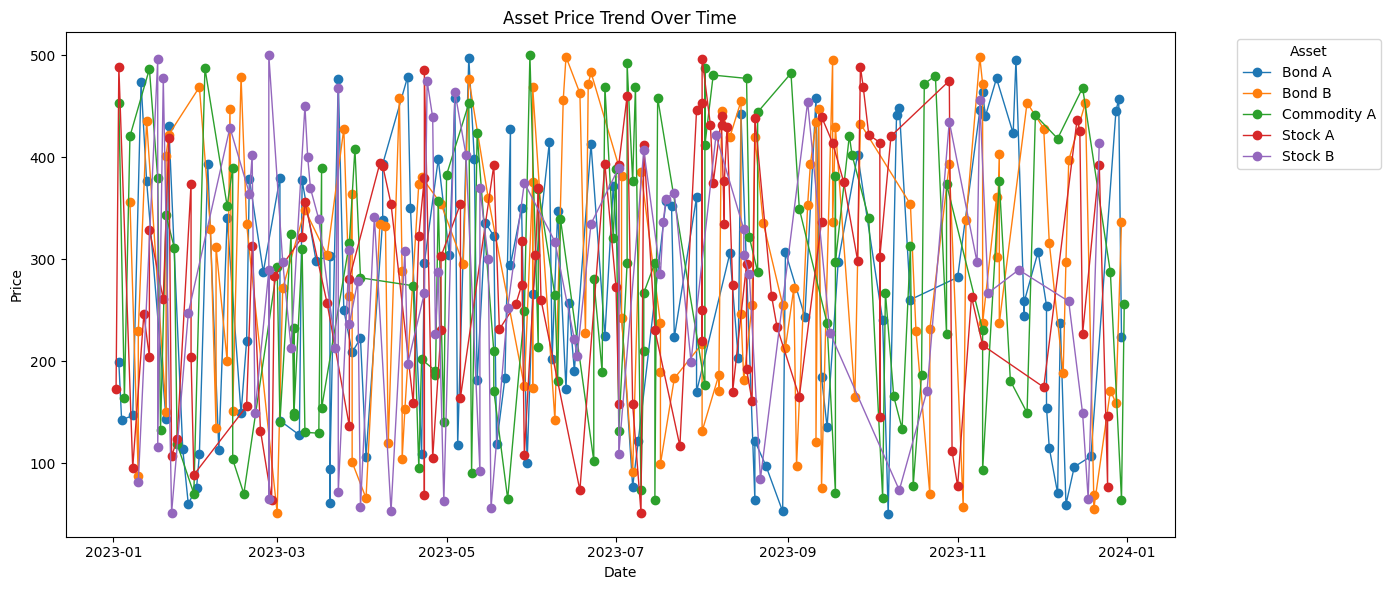

In [50]:
plt.figure(figsize=(14, 6))

for asset in df["asset"].unique():
    asset_data = df[df["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        marker="o",
        linewidth=1,
        label=asset
    )

plt.title("Asset Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(title="Asset", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_asset_price_trend_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Individual Asset Price Trends

The combined chart can become crowded if there are many assets.

Here we create a separate trend chart for each asset.

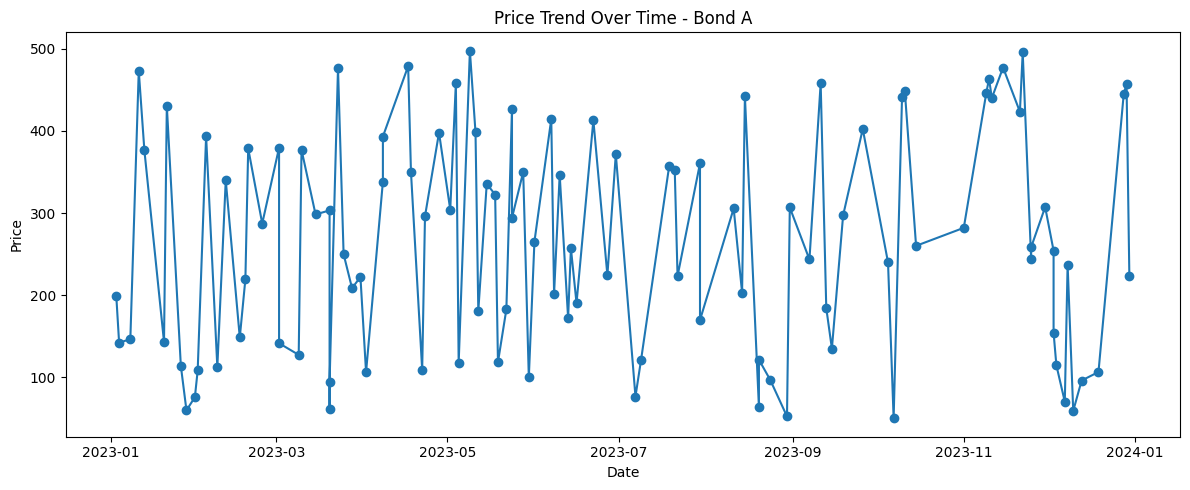

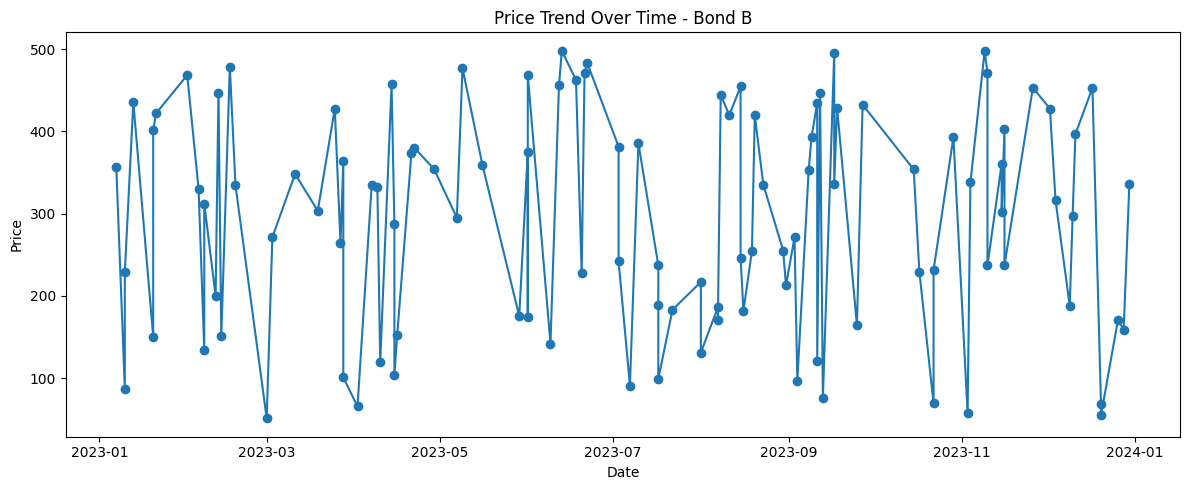

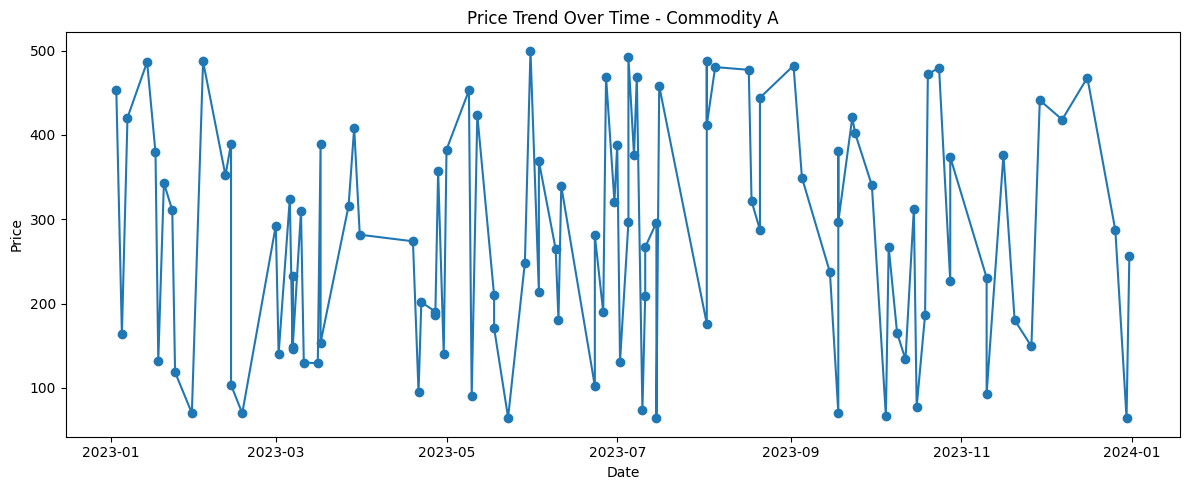

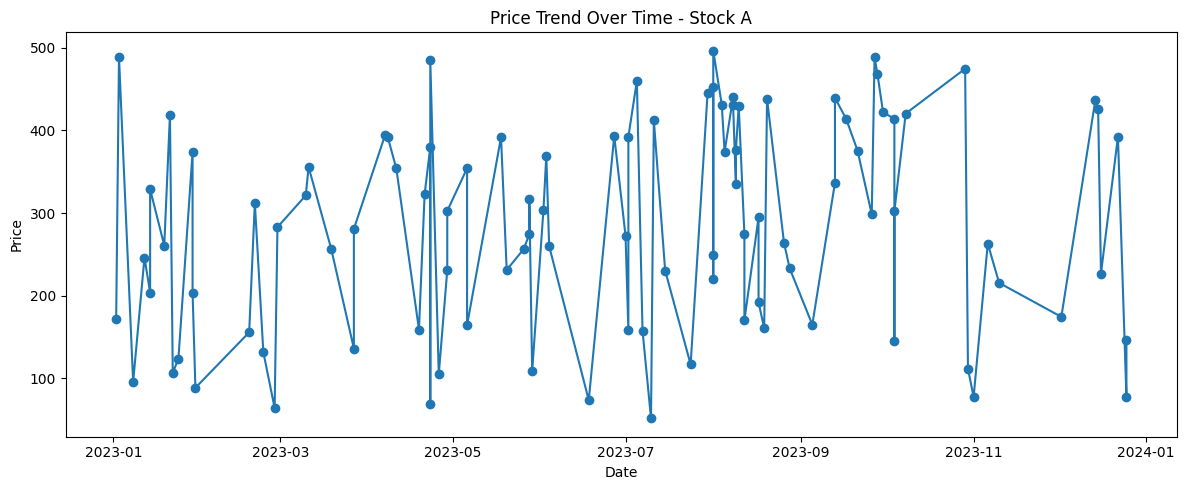

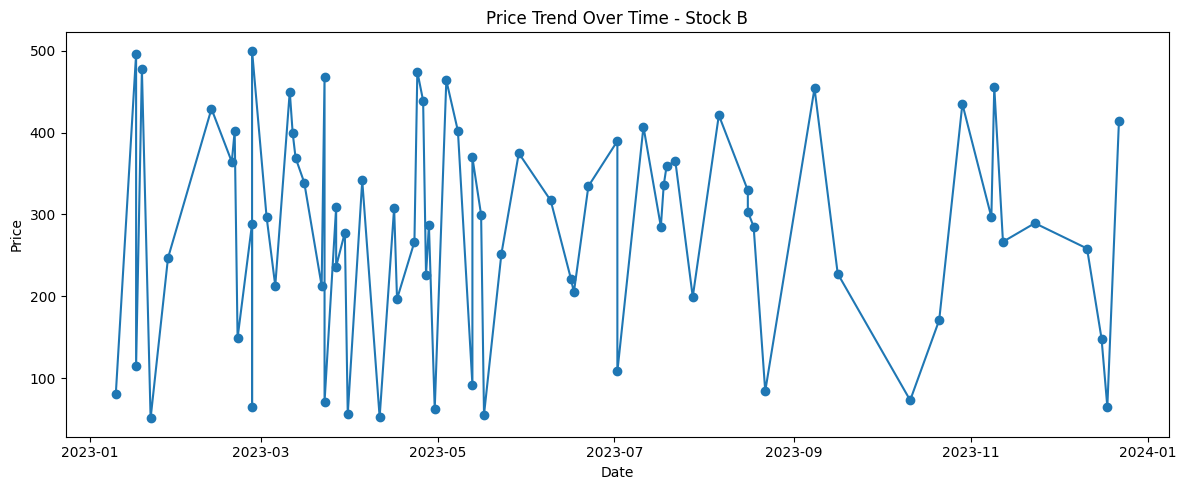

In [51]:
for asset in df["asset"].unique():
    asset_data = df[df["asset"] == asset].sort_values("date")

    plt.figure(figsize=(12, 5))
    plt.plot(asset_data["date"], asset_data["price"], marker="o", linewidth=1.5)
    plt.title(f"Price Trend Over Time - {asset}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.tight_layout()

    safe_asset_name = str(asset).replace(" ", "_").replace("/", "_").lower()
    plt.savefig(
        FIGURES_DIR / f"02_price_trend_{safe_asset_name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 11. Daily Average Price

Since the dataset contains multiple assets, we calculate the average asset price for each date.

This gives a high-level portfolio-like trend.

In [52]:
daily_average_price = (
    df.groupby("date", as_index=False)
    .agg(
        average_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        asset_count=("asset", "nunique")
    )
    .sort_values("date")
)

daily_average_price.head()

,date,average_price,min_price,max_price,asset_count
0,2023-01-02,172.1500,172.1500,172.1500,1
1,2023-01-03,380.1367,198.6100,488.5700,3
2,2023-01-04,142.2400,142.2400,142.2400,1
3,2023-01-05,163.7700,163.7700,163.7700,1
4,2023-01-07,388.3800,356.3400,420.4200,2


## 12. Daily Average Price Trend

This chart shows the average price movement across all assets over time.

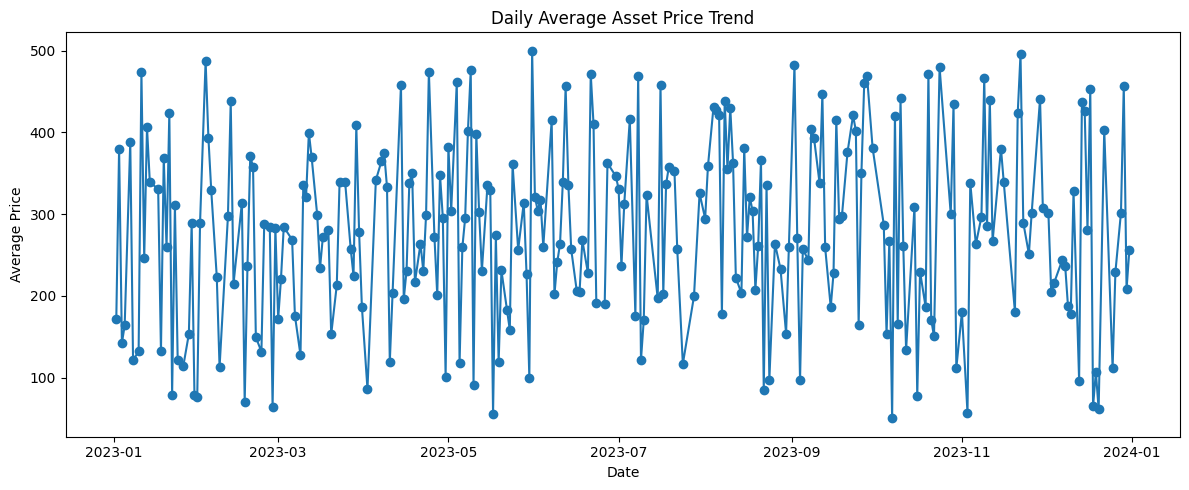

In [53]:
plt.figure(figsize=(12, 5))
plt.plot(
    daily_average_price["date"],
    daily_average_price["average_price"],
    marker="o",
    linewidth=1.5
)
plt.title("Daily Average Asset Price Trend")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_daily_average_price_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Create Daily Returns

Daily return measures percentage price change from the previous record.

Formula:

daily_return = current_price / previous_price - 1

Daily returns are useful for:

- Measuring volatility
- Detecting sudden movements
- Building anomaly detection feature

In [54]:
df_returns = df.sort_values(["asset", "date"]).copy()

df_returns["daily_return"] = (
    df_returns.groupby("asset")["price"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

df_returns["daily_return"] = df_returns["daily_return"].fillna(0)

df_returns.head(10)

,date,asset,price,daily_return
0,2023-01-03,Bond A,198.6100,0.0000
1,2023-01-04,Bond A,142.2400,-0.2838
2,2023-01-08,Bond A,146.5800,0.0305
3,2023-01-11,Bond A,473.2000,2.2283
4,2023-01-13,Bond A,376.5700,-0.2042
5,2023-01-20,Bond A,143.1900,-0.6198
6,2023-01-21,Bond A,430.6300,2.0074
7,2023-01-26,Bond A,113.9800,-0.7353
8,2023-01-28,Bond A,59.9100,-0.4744
9,2023-01-31,Bond A,75.9700,0.2681


## 14. Daily Return Summary by Asset

This table shows return behavior for each asset.

Important metrics:

- Average return
- Minimum return
- Maximum return
- Standard deviation of return

In [55]:
return_summary = (
    df_returns.groupby("asset")
    .agg(
        average_return=("daily_return", "mean"),
        min_return=("daily_return", "min"),
        max_return=("daily_return", "max"),
        return_std=("daily_return", "std"),
        positive_return_days=("daily_return", lambda x: (x > 0).sum()),
        negative_return_days=("daily_return", lambda x: (x < 0).sum())
    )
    .reset_index()
    .sort_values("return_std", ascending=False)
)

return_summary

,asset,average_return,min_return,max_return,return_std,positive_return_days,negative_return_days
4,Stock B,0.7070,-0.8925,6.7271,1.8820,33,40
0,Bond A,0.3718,-0.8559,7.7926,1.2772,54,54
2,Commodity A,0.4091,-0.8433,5.9549,1.2766,48,57
3,Stock A,0.3569,-0.8183,7.0136,1.2753,48,52
1,Bond B,0.3885,-0.8544,5.5226,1.2369,53,56


## 15. Daily Return Distribution

This histogram shows how daily returns are distributed.

Wide spread indicates high volatility.

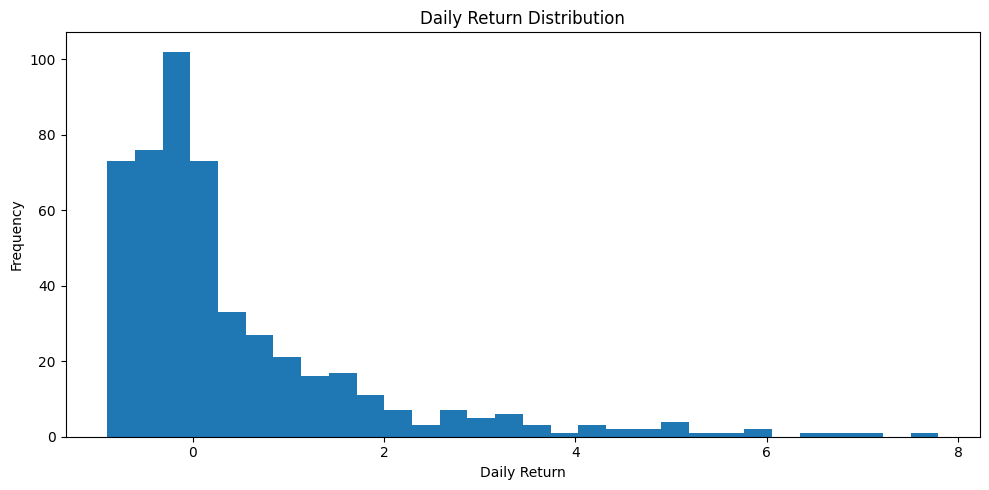

In [56]:
plt.figure(figsize=(10, 5))
plt.hist(df_returns["daily_return"], bins=30)
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_daily_return_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Daily Return Trend by Asset

This chart shows how returns change over time for each asset.

Large spikes may indicate possible anomalies.

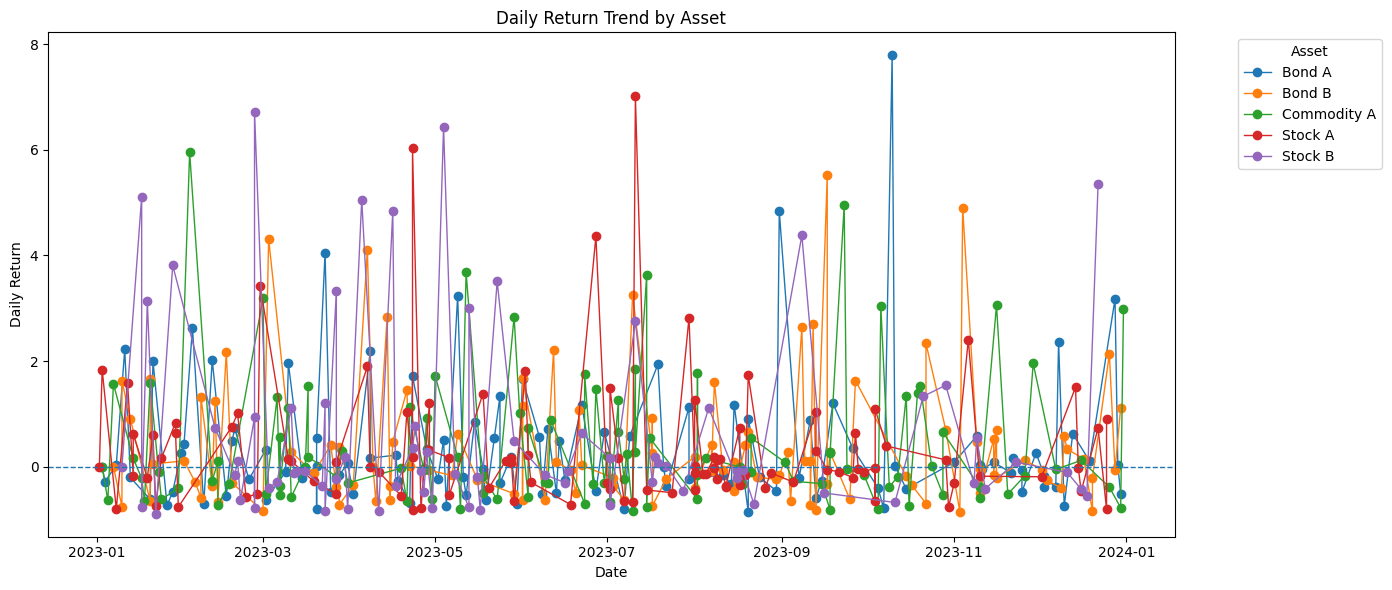

In [57]:
plt.figure(figsize=(14, 6))

for asset in df_returns["asset"].unique():
    asset_data = df_returns[df_returns["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["daily_return"],
        marker="o",
        linewidth=1,
        label=asset
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Daily Return Trend by Asset")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend(title="Asset", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_daily_return_trend_by_asset.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Rolling Average Features

Rolling averages smooth short-term fluctuations and help reveal longer-term trends.

We calculate:

- 7-period rolling average
- 14-period rolling average
- 30-period rolling average

In [58]:
df_rolling = df_returns.copy()

rolling_windows = [7, 14, 30]

rolling_mean_columns = []

for window in rolling_windows:
    column_name = f"price_rolling_mean_{window}"
    rolling_mean_columns.append(column_name)

    df_rolling[column_name] = (
        df_rolling.groupby("asset")["price"]
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )

df_rolling.head()

,date,asset,price,daily_return,price_rolling_mean_7,price_rolling_mean_14,price_rolling_mean_30
0,2023-01-03,Bond A,198.6100,0.0000,198.6100,198.6100,198.6100
1,2023-01-04,Bond A,142.2400,-0.2838,170.4250,170.4250,170.4250
2,2023-01-08,Bond A,146.5800,0.0305,162.4767,162.4767,162.4767
3,2023-01-11,Bond A,473.2000,2.2283,240.1575,240.1575,240.1575
4,2023-01-13,Bond A,376.5700,-0.2042,267.4400,267.4400,267.4400


## 18. Rolling Average Trend by Asset

Rolling average charts help us compare actual price with smoothed price trends.

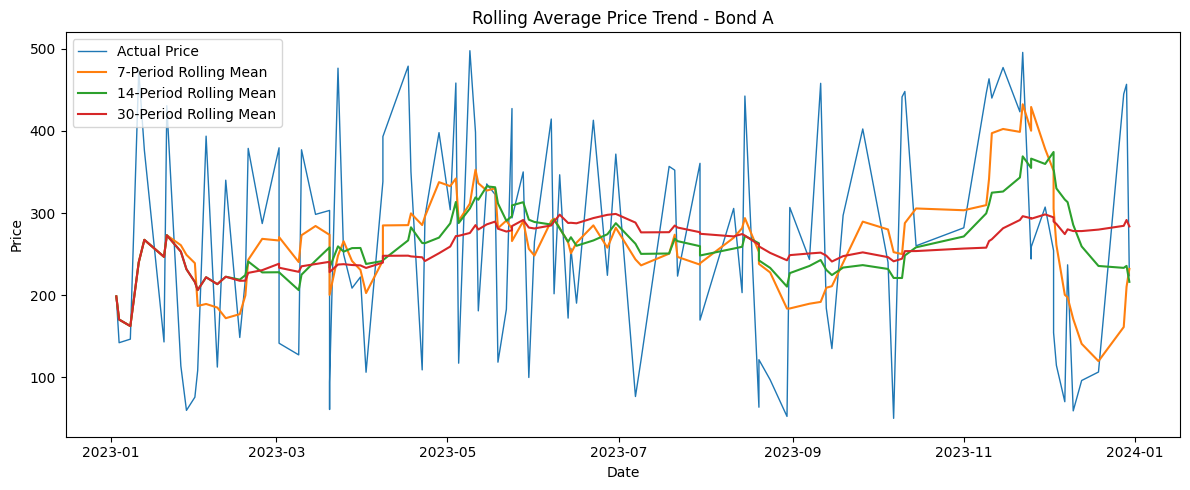

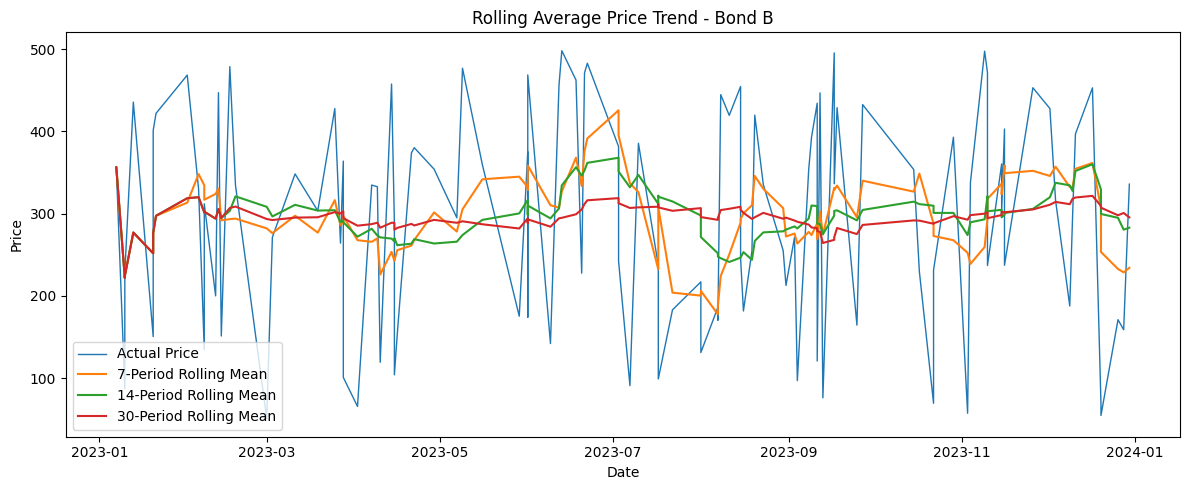

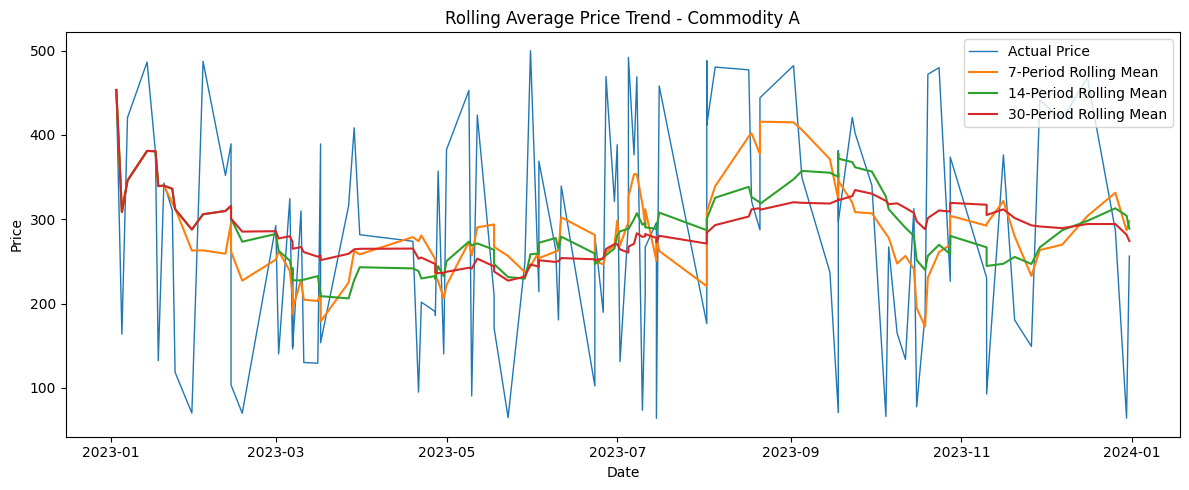

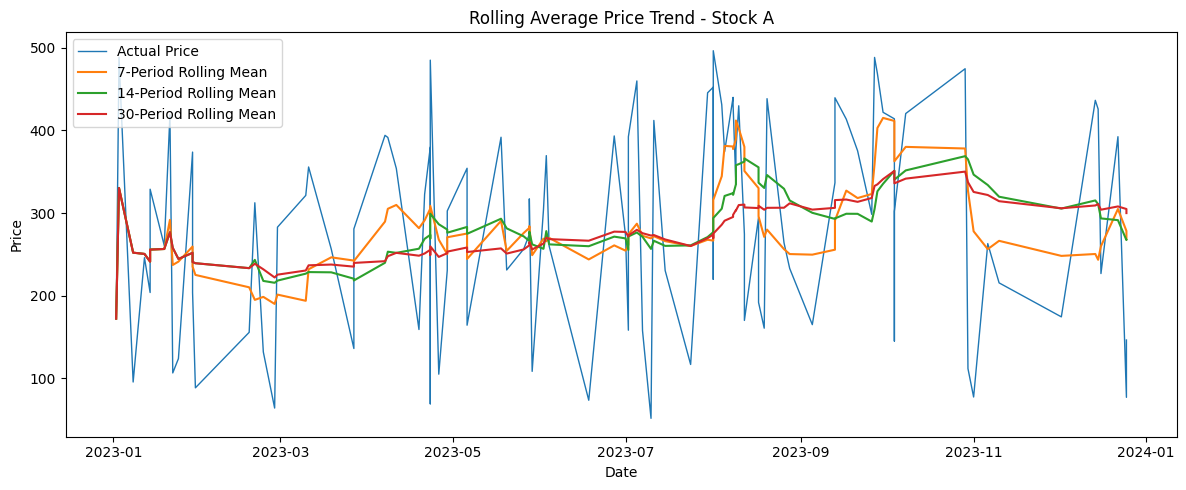

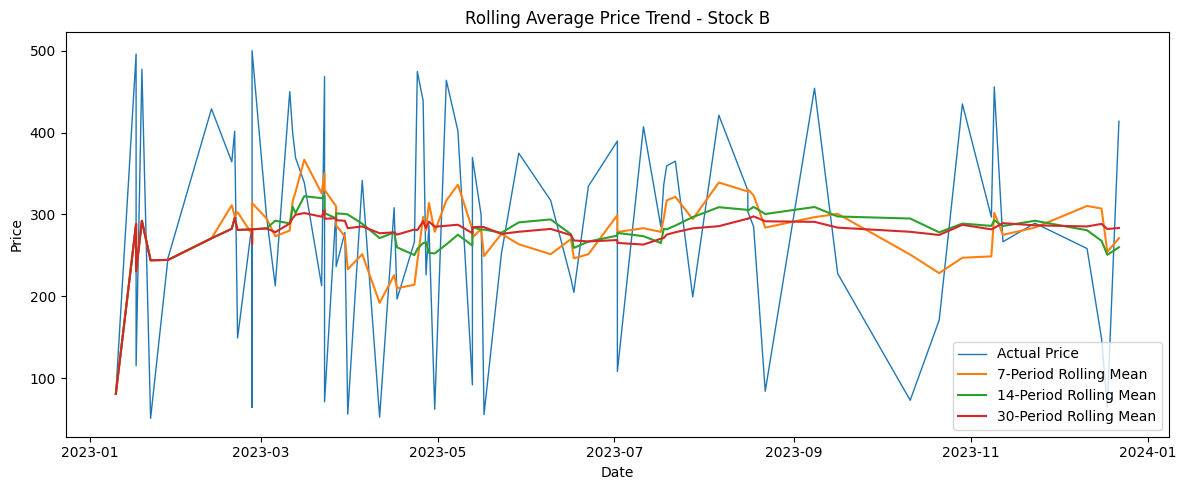

In [59]:
for asset in df_rolling["asset"].unique():
    asset_data = df_rolling[df_rolling["asset"] == asset].sort_values("date")

    plt.figure(figsize=(12, 5))
    plt.plot(asset_data["date"], asset_data["price"], label="Actual Price", linewidth=1)
    plt.plot(asset_data["date"], asset_data["price_rolling_mean_7"], label="7-Period Rolling Mean", linewidth=1.5)
    plt.plot(asset_data["date"], asset_data["price_rolling_mean_14"], label="14-Period Rolling Mean", linewidth=1.5)
    plt.plot(asset_data["date"], asset_data["price_rolling_mean_30"], label="30-Period Rolling Mean", linewidth=1.5)

    plt.title(f"Rolling Average Price Trend - {asset}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()

    safe_asset_name = str(asset).replace(" ", "_").replace("/", "_").lower()
    plt.savefig(
        FIGURES_DIR / f"02_rolling_average_{safe_asset_name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 19. Rolling Volatility

Rolling volatility measures how unstable or risky an asset's returns are over time.

Here we calculate rolling standard deviation of daily returns.

In [60]:
volatility_windows = [7, 14, 30]

for window in volatility_windows:
    column_name = f"return_rolling_volatility_{window}"

    df_rolling[column_name] = (
        df_rolling.groupby("asset")["daily_return"]
        .transform(lambda x: x.rolling(window=window, min_periods=1).std())
    )

df_rolling = df_rolling.fillna(0)

df_rolling.head()

,date,asset,price,daily_return,price_rolling_mean_7,price_rolling_mean_14,price_rolling_mean_30,return_rolling_volatility_7,return_rolling_volatility_14,return_rolling_volatility_30
0,2023-01-03,Bond A,198.6100,0.0000,198.6100,198.6100,198.6100,0.0000,0.0000,0.0000
1,2023-01-04,Bond A,142.2400,-0.2838,170.4250,170.4250,170.4250,0.2007,0.2007,0.2007
2,2023-01-08,Bond A,146.5800,0.0305,162.4767,162.4767,162.4767,0.1733,0.1733,0.1733
3,2023-01-11,Bond A,473.2000,2.2283,240.1575,240.1575,240.1575,1.1650,1.1650,1.1650
4,2023-01-13,Bond A,376.5700,-0.2042,267.4400,267.4400,267.4400,1.0561,1.0561,1.0561


## 20. Rolling Volatility Trend

This chart shows volatility movement for each asset.

High volatility periods are important for risk monitoring and anomaly detection.

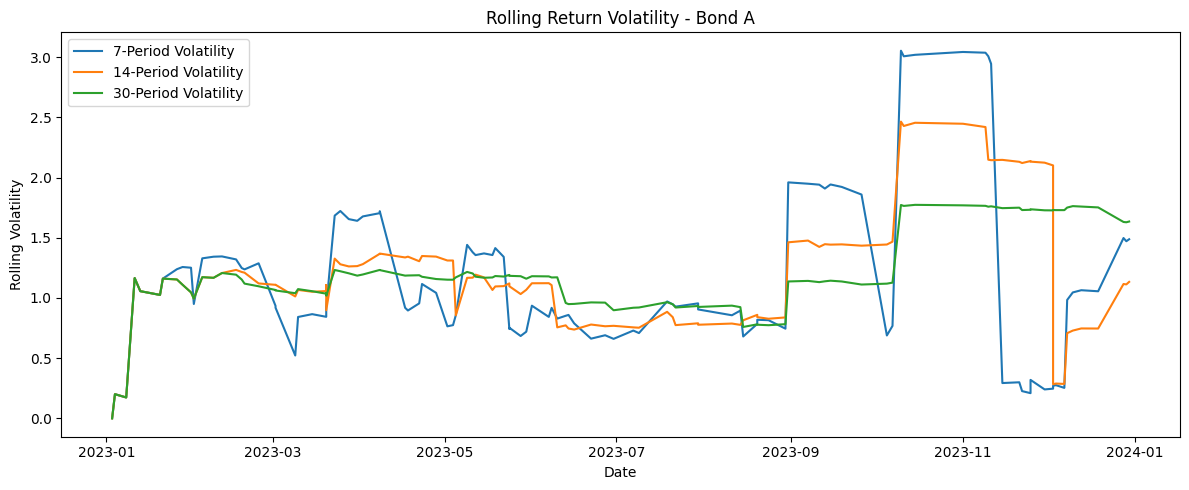

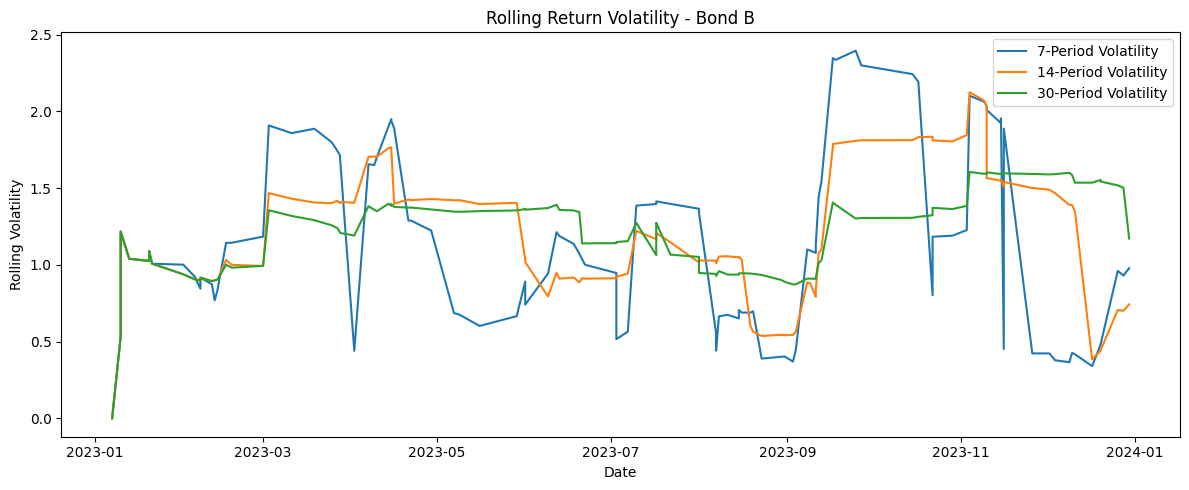

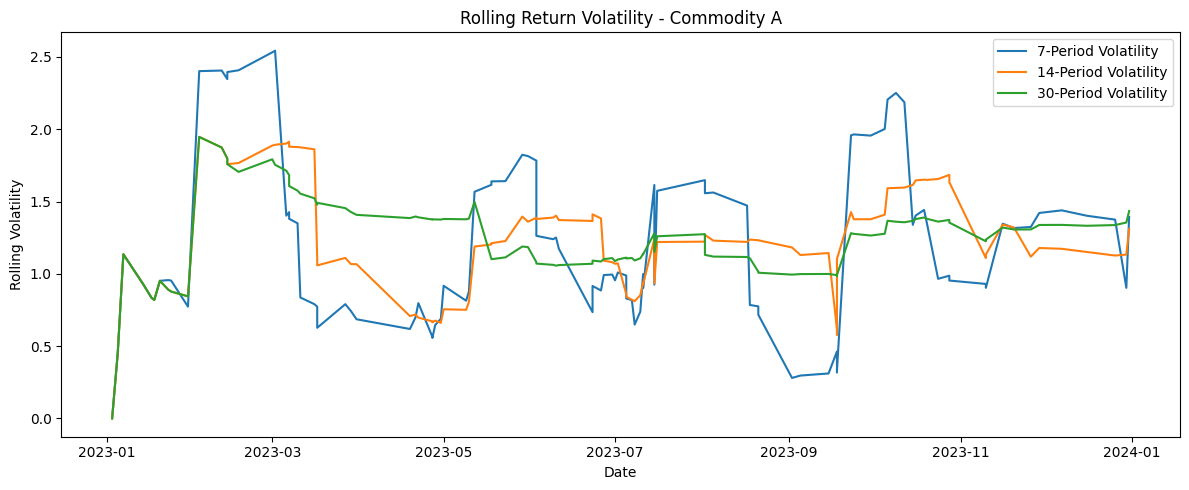

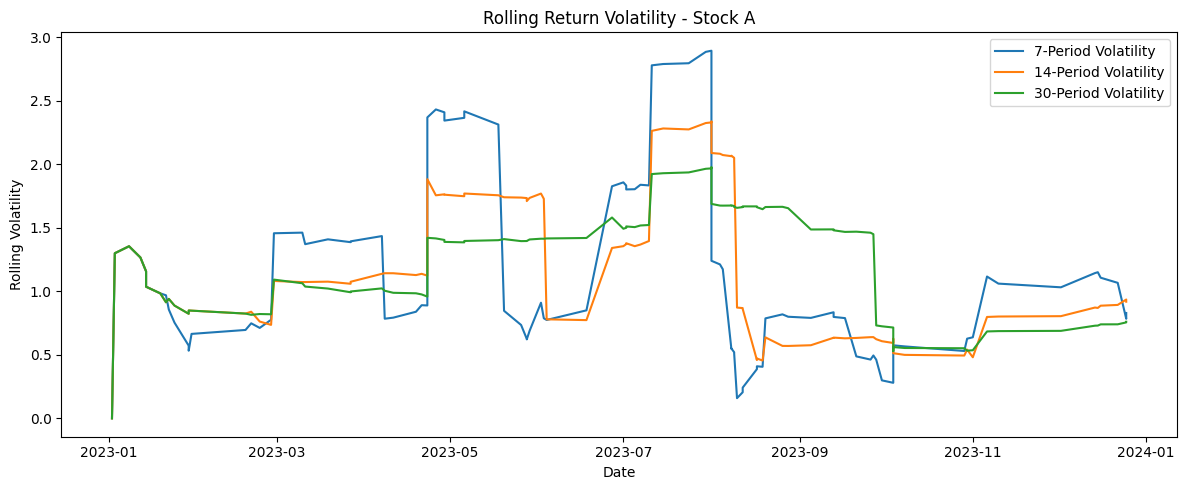

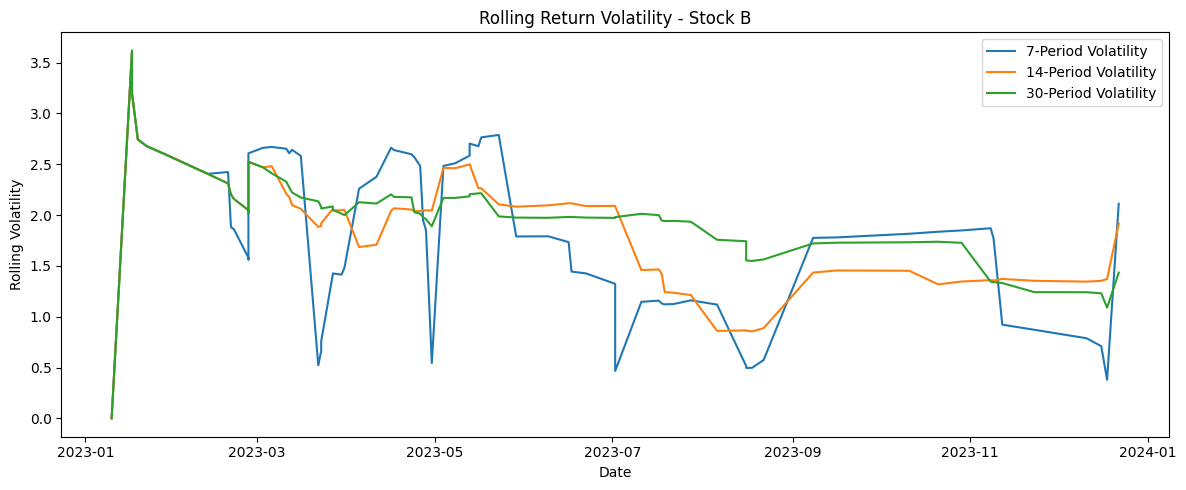

In [61]:
for asset in df_rolling["asset"].unique():
    asset_data = df_rolling[df_rolling["asset"] == asset].sort_values("date")

    plt.figure(figsize=(12, 5))
    plt.plot(
        asset_data["date"],
        asset_data["return_rolling_volatility_7"],
        label="7-Period Volatility",
        linewidth=1.5
    )
    plt.plot(
        asset_data["date"],
        asset_data["return_rolling_volatility_14"],
        label="14-Period Volatility",
        linewidth=1.5
    )
    plt.plot(
        asset_data["date"],
        asset_data["return_rolling_volatility_30"],
        label="30-Period Volatility",
        linewidth=1.5
    )

    plt.title(f"Rolling Return Volatility - {asset}")
    plt.xlabel("Date")
    plt.ylabel("Rolling Volatility")
    plt.legend()
    plt.tight_layout()

    safe_asset_name = str(asset).replace(" ", "_").replace("/", "_").lower()
    plt.savefig(
        FIGURES_DIR / f"02_rolling_volatility_{safe_asset_name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 21. Monthly Price Trend

Monthly aggregation helps us understand broader movement patterns.

We calculate average monthly price for each asset.

In [62]:
df_monthly = df.copy()

df_monthly["year"] = df_monthly["date"].dt.year
df_monthly["month"] = df_monthly["date"].dt.month
df_monthly["year_month"] = df_monthly["date"].dt.to_period("M").astype(str)

monthly_asset_price = (
    df_monthly.groupby(["year_month", "asset"], as_index=False)
    .agg(
        average_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        record_count=("price", "count")
    )
    .sort_values(["asset", "year_month"])
)

monthly_asset_price.head()

,year_month,asset,average_price,min_price,max_price,record_count
0,2023-01,Bond A,216.0880,59.9100,473.2000,10
5,2023-02,Bond A,248.6150,108.4700,393.6100,8
10,2023-03,Bond A,244.9600,61.0200,476.3300,12
15,2023-04,Bond A,308.7212,106.3100,478.8000,8
20,2023-05,Bond A,291.9500,99.9400,497.5900,14


## 22. Monthly Average Price by Asset

This chart compares monthly average price movement across assets.

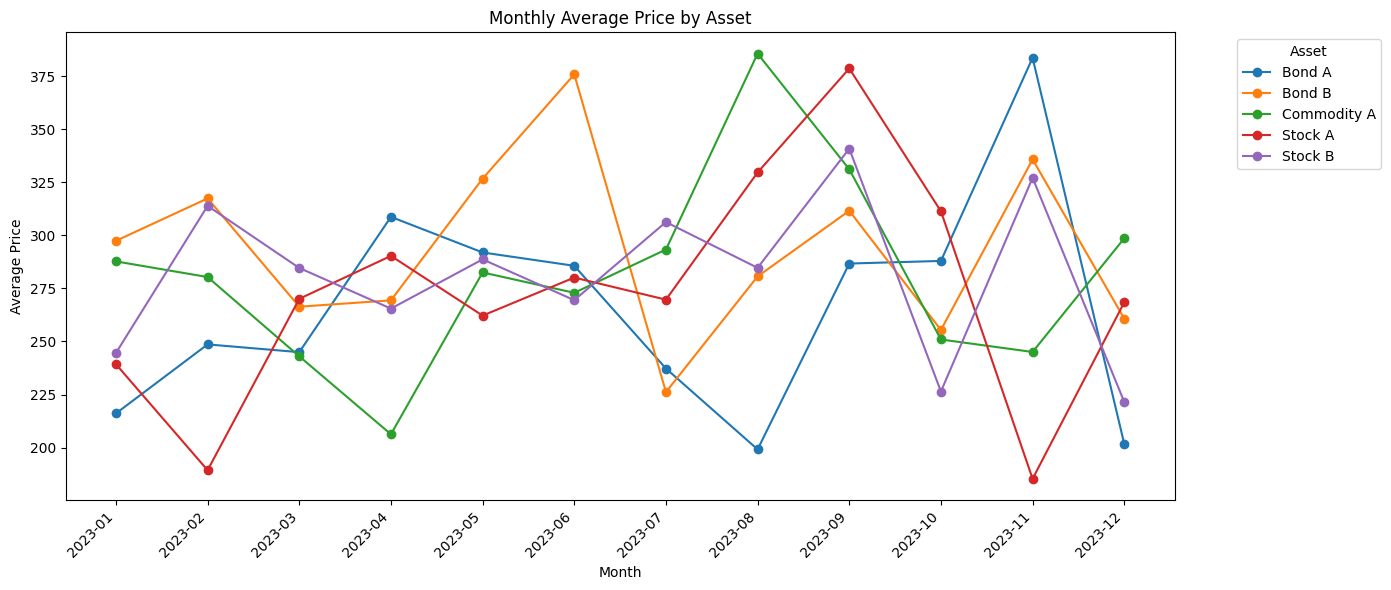

In [63]:
plt.figure(figsize=(14, 6))

for asset in monthly_asset_price["asset"].unique():
    asset_data = monthly_asset_price[monthly_asset_price["asset"] == asset]
    plt.plot(
        asset_data["year_month"],
        asset_data["average_price"],
        marker="o",
        linewidth=1.5,
        label=asset
    )

plt.title("Monthly Average Price by Asset")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Asset", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_monthly_average_price_by_asset.png", dpi=300, bbox_inches="tight")
plt.show()

## 23. Highest and Lowest Price Records

This section shows the highest and lowest price observations in the dataset.

In [64]:
highest_prices = df.sort_values("price", ascending=False).head(10)
lowest_prices = df.sort_values("price", ascending=True).head(10)

print("Highest price records:")
display(highest_prices)

print("Lowest price records:")
display(lowest_prices)

Highest price records:


,date,asset,price
438,2023-02-26,Stock B,499.7900
263,2023-05-31,Commodity A,499.7600
153,2023-06-13,Bond B,498.2600
200,2023-11-09,Bond B,497.7400
41,2023-05-09,Bond A,497.5900
385,2023-08-01,Stock A,496.6000
427,2023-01-17,Stock B,495.7500
188,2023-09-17,Bond B,495.5900
94,2023-11-22,Bond A,495.5400
277,2023-07-05,Commodity A,491.7400


Lowest price records:


,date,asset,price
84,2023-10-07,Bond A,50.2000
125,2023-03-01,Bond B,51.0400
430,2023-01-22,Stock B,51.3000
377,2023-07-10,Stock A,51.4300
75,2023-08-30,Bond A,52.5500
453,2023-04-11,Stock B,52.7400
215,2023-12-20,Bond B,54.5400
467,2023-05-17,Stock B,55.8600
451,2023-03-31,Stock B,56.3900
198,2023-11-03,Bond B,57.2300


## 24. Asset Price Ranking

We rank assets by:

- Average price
- Maximum price
- Price volatility

In [65]:
asset_price_ranking = (
    df_returns.groupby("asset")
    .agg(
        average_price=("price", "mean"),
        max_price=("price", "max"),
        min_price=("price", "min"),
        price_std=("price", "std"),
        return_std=("daily_return", "std")
    )
    .reset_index()
    .sort_values("average_price", ascending=False)
)

asset_price_ranking

,asset,average_price,max_price,min_price,price_std,return_std
1,Bond B,294.4699,498.2600,51.0400,131.6930,1.2369
3,Stock A,284.8642,496.6000,51.4300,125.3389,1.2753
4,Stock B,281.5776,499.7900,51.3000,131.6725,1.8820
2,Commodity A,280.2518,499.7600,63.8600,133.9463,1.2766
0,Bond A,265.8024,497.5900,50.2000,132.7395,1.2772


## 25. Average Price by Asset

This bar chart compares the average price of each asset.

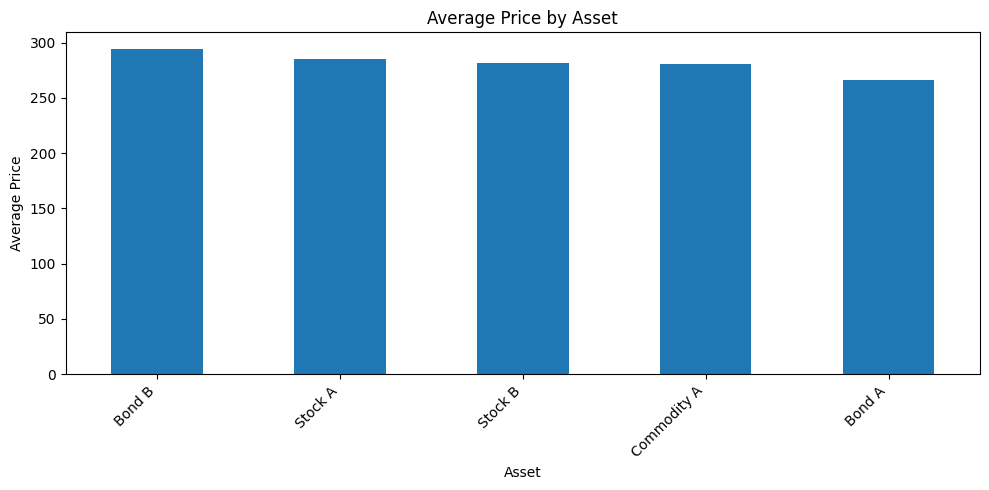

In [66]:
average_price_by_asset = (
    df.groupby("asset")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
average_price_by_asset.plot(kind="bar")
plt.title("Average Price by Asset")
plt.xlabel("Asset")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_average_price_by_asset.png", dpi=300, bbox_inches="tight")
plt.show()

## 26. Volatility Ranking by Asset

Assets with higher return standard deviation are more volatile.

This is useful for risk analysis.

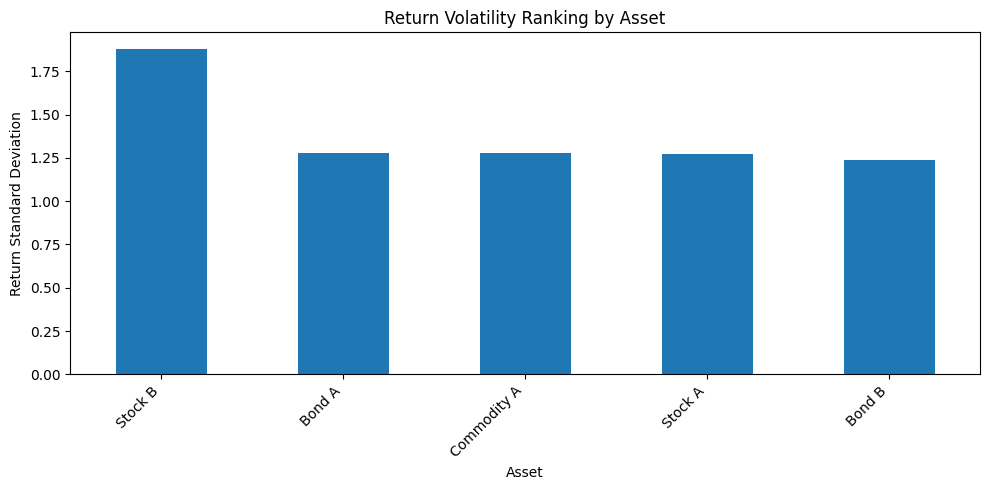

asset
Stock B       1.8820
Bond A        1.2772
Commodity A   1.2766
Stock A       1.2753
Bond B        1.2369
Name: daily_return, dtype: float64

In [67]:
volatility_ranking = (
    df_returns.groupby("asset")["daily_return"]
    .std()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
volatility_ranking.plot(kind="bar")
plt.title("Return Volatility Ranking by Asset")
plt.xlabel("Asset")
plt.ylabel("Return Standard Deviation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_volatility_ranking_by_asset.png", dpi=300, bbox_inches="tight")
plt.show()

volatility_ranking

## 27. Simple Anomaly Check Using Z-Score

A z-score shows how far a value is from the mean.

Formula:

```text
z_score = (price - mean_price) / standard_deviation

A common rule is:

- z-score greater than 3 = possible high anomaly
- z-score less than -3 = possible low anomaly

In [68]:
df_anomaly_check = df.copy()

df_anomaly_check["price_z_score"] = (
    df_anomaly_check.groupby("asset")["price"]
    .transform(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0)
)

df_anomaly_check["is_possible_anomaly_zscore"] = (
    df_anomaly_check["price_z_score"].abs() > 3
)

zscore_anomalies = df_anomaly_check[df_anomaly_check["is_possible_anomaly_zscore"]]

print("Possible anomalies detected using z-score:", len(zscore_anomalies))

zscore_anomalies.head()

Possible anomalies detected using z-score: 0


,date,asset,price,price_z_score,is_possible_anomaly_zscore


## 28. Simple Anomaly Check Using IQR by Asset

We also detect possible price anomalies using the IQR method separately for each asset.

In [69]:
def detect_iqr_anomalies(group):
    q1 = group["price"].quantile(0.25)
    q3 = group["price"].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    group = group.copy()
    group["iqr_lower_bound"] = lower_bound
    group["iqr_upper_bound"] = upper_bound
    group["is_possible_anomaly_iqr"] = (
        (group["price"] < lower_bound) |
        (group["price"] > upper_bound)
    )

    return group

df_iqr_anomaly = (
    df.groupby("asset", group_keys=False)
    .apply(detect_iqr_anomalies)
)

iqr_anomalies = df_iqr_anomaly[df_iqr_anomaly["is_possible_anomaly_iqr"]]

print("Possible anomalies detected using IQR:", len(iqr_anomalies))

iqr_anomalies.head()

Possible anomalies detected using IQR: 0


,date,price,iqr_lower_bound,iqr_upper_bound,is_possible_anomaly_iqr


## 29. Visualize Possible IQR Anomalies

This chart marks possible anomalies detected using the IQR method.

In [70]:
df_iqr_anomaly = df_returns.copy()

q1 = df_iqr_anomaly.groupby("asset")["price"].transform(lambda x: x.quantile(0.25))
q3 = df_iqr_anomaly.groupby("asset")["price"].transform(lambda x: x.quantile(0.75))

iqr = q3 - q1

df_iqr_anomaly["iqr_lower_bound"] = q1 - 1.5 * iqr
df_iqr_anomaly["iqr_upper_bound"] = q3 + 1.5 * iqr

df_iqr_anomaly["is_possible_anomaly_iqr"] = (
    (df_iqr_anomaly["price"] < df_iqr_anomaly["iqr_lower_bound"])
    | (df_iqr_anomaly["price"] > df_iqr_anomaly["iqr_upper_bound"])
)

df_iqr_anomaly.head()

,date,asset,price,daily_return,iqr_lower_bound,iqr_upper_bound,is_possible_anomaly_iqr
0,2023-01-03,Bond A,198.6100,0.0000,-212.4800,733.4400,False
1,2023-01-04,Bond A,142.2400,-0.2838,-212.4800,733.4400,False
2,2023-01-08,Bond A,146.5800,0.0305,-212.4800,733.4400,False
3,2023-01-11,Bond A,473.2000,2.2283,-212.4800,733.4400,False
4,2023-01-13,Bond A,376.5700,-0.2042,-212.4800,733.4400,False


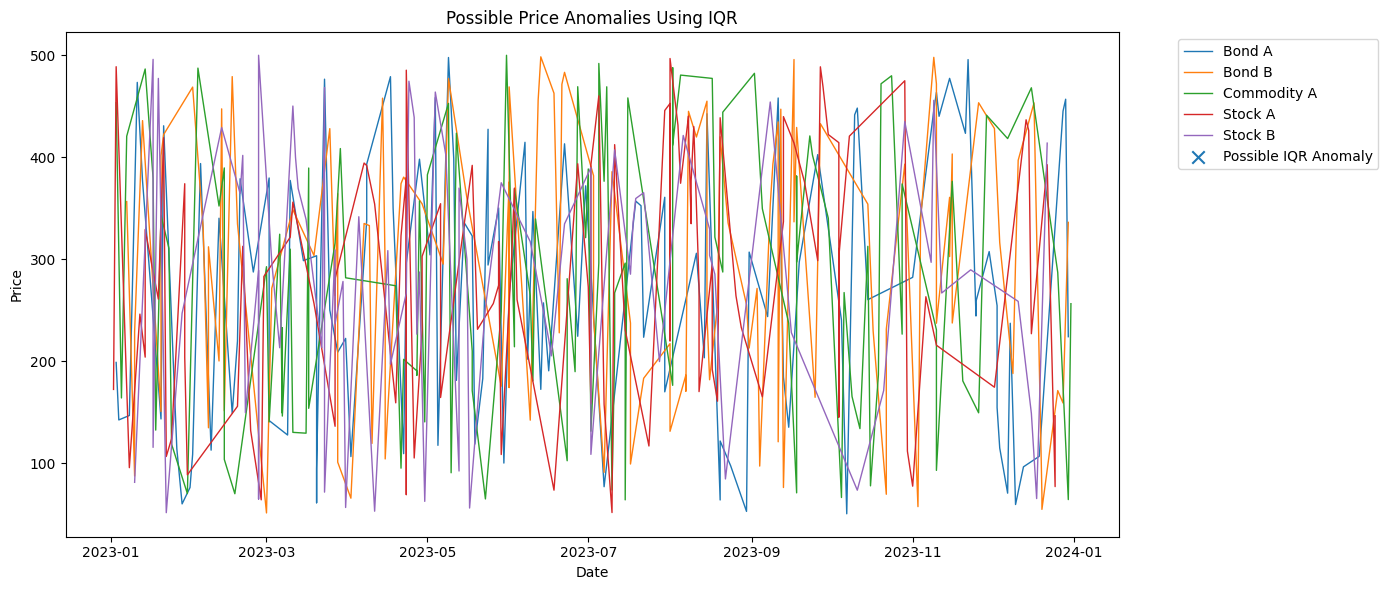

In [71]:
plt.figure(figsize=(14, 6))

for asset in df_iqr_anomaly["asset"].unique():
    asset_data = df_iqr_anomaly[df_iqr_anomaly["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        linewidth=1,
        label=asset
    )

anomaly_points = df_iqr_anomaly[df_iqr_anomaly["is_possible_anomaly_iqr"]]

plt.scatter(
    anomaly_points["date"],
    anomaly_points["price"],
    marker="x",
    s=80,
    label="Possible IQR Anomaly"
)

plt.title("Possible Price Anomalies Using IQR")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_possible_iqr_anomalies.png", dpi=300, bbox_inches="tight")
plt.show()

## 30. Time-Based Feature Creation

We create time-based features that will be useful for forecasting models.

Features include:

- Year
- Month
- Quarter
- Day
- Day of week
- Week of year
- Month start
- Month end

In [72]:
df_features = df_rolling.copy()

df_features["year"] = df_features["date"].dt.year
df_features["month"] = df_features["date"].dt.month
df_features["quarter"] = df_features["date"].dt.quarter
df_features["day"] = df_features["date"].dt.day
df_features["day_of_week"] = df_features["date"].dt.dayofweek
df_features["week_of_year"] = df_features["date"].dt.isocalendar().week.astype(int)
df_features["is_month_start"] = df_features["date"].dt.is_month_start.astype(int)
df_features["is_month_end"] = df_features["date"].dt.is_month_end.astype(int)

df_features.head()

,date,asset,price,daily_return,price_rolling_mean_7,price_rolling_mean_14,price_rolling_mean_30,return_rolling_volatility_7,return_rolling_volatility_14,return_rolling_volatility_30,year,month,quarter,day,day_of_week,week_of_year,is_month_start,is_month_end
0,2023-01-03,Bond A,198.6100,0.0000,198.6100,198.6100,198.6100,0.0000,0.0000,0.0000,2023,1,1,3,1,1,0,0
1,2023-01-04,Bond A,142.2400,-0.2838,170.4250,170.4250,170.4250,0.2007,0.2007,0.2007,2023,1,1,4,2,1,0,0
2,2023-01-08,Bond A,146.5800,0.0305,162.4767,162.4767,162.4767,0.1733,0.1733,0.1733,2023,1,1,8,6,1,0,0
3,2023-01-11,Bond A,473.2000,2.2283,240.1575,240.1575,240.1575,1.1650,1.1650,1.1650,2023,1,1,11,2,2,0,0
4,2023-01-13,Bond A,376.5700,-0.2042,267.4400,267.4400,267.4400,1.0561,1.0561,1.0561,2023,1,1,13,4,2,0,0


## 31. Lag Feature Creation

Lag features help forecasting models learn from previous price values.

We create:

- Previous 1-period price
- Previous 3-period price
- Previous 7-period price

In [73]:
lag_periods = [1, 3, 7]

for lag in lag_periods:
    df_features[f"price_lag_{lag}"] = (
        df_features.groupby("asset")["price"]
        .shift(lag)
    )

df_features = df_features.replace([np.inf, -np.inf], np.nan)
df_features = df_features.fillna(0)

df_features.head(10)

,date,asset,price,daily_return,price_rolling_mean_7,price_rolling_mean_14,price_rolling_mean_30,return_rolling_volatility_7,return_rolling_volatility_14,return_rolling_volatility_30,year,month,quarter,day,day_of_week,week_of_year,is_month_start,is_month_end,price_lag_1,price_lag_3,price_lag_7
0,2023-01-03,Bond A,198.6100,0.0000,198.6100,198.6100,198.6100,0.0000,0.0000,0.0000,2023,1,1,3,1,1,0,0,0.0000,0.0000,0.0000
1,2023-01-04,Bond A,142.2400,-0.2838,170.4250,170.4250,170.4250,0.2007,0.2007,0.2007,2023,1,1,4,2,1,0,0,198.6100,0.0000,0.0000
2,2023-01-08,Bond A,146.5800,0.0305,162.4767,162.4767,162.4767,0.1733,0.1733,0.1733,2023,1,1,8,6,1,0,0,142.2400,0.0000,0.0000
3,2023-01-11,Bond A,473.2000,2.2283,240.1575,240.1575,240.1575,1.1650,1.1650,1.1650,2023,1,1,11,2,2,0,0,146.5800,198.6100,0.0000
4,2023-01-13,Bond A,376.5700,-0.2042,267.4400,267.4400,267.4400,1.0561,1.0561,1.0561,2023,1,1,13,4,2,0,0,473.2000,142.2400,0.0000
5,2023-01-20,Bond A,143.1900,-0.6198,246.7317,246.7317,246.7317,1.0249,1.0249,1.0249,2023,1,1,20,4,3,0,0,376.5700,146.5800,0.0000
6,2023-01-21,Bond A,430.6300,2.0074,273.0029,273.0029,273.0029,1.1602,1.1602,1.1602,2023,1,1,21,5,3,0,0,143.1900,473.2000,0.0000
7,2023-01-26,Bond A,113.9800,-0.7353,260.9129,253.1250,253.1250,1.2386,1.1532,1.1532,2023,1,1,26,3,4,0,0,430.6300,376.5700,198.6100
8,2023-01-28,Bond A,59.9100,-0.4744,249.1514,231.6567,231.6567,1.2567,1.1094,1.1094,2023,1,1,28,5,4,0,0,113.9800,143.1900,142.2400
9,2023-01-31,Bond A,75.9700,0.2681,239.0643,216.0880,216.0880,1.2508,1.0461,1.0461,2023,1,1,31,1,5,0,1,59.9100,430.6300,146.5800


## 32. Correlation Analysis

We analyze correlation between numerical features.

This helps identify which engineered features may be useful for forecasting.

In [74]:
numeric_columns = df_features.select_dtypes(include=["number"]).columns.tolist()

correlation_matrix = df_features[numeric_columns].corr()

correlation_matrix

,price,daily_return,price_rolling_mean_7,price_rolling_mean_14,price_rolling_mean_30,return_rolling_volatility_7,return_rolling_volatility_14,return_rolling_volatility_30,year,month,quarter,day,day_of_week,week_of_year,is_month_start,is_month_end,price_lag_1,price_lag_3,price_lag_7
price,1.0000,0.4827,0.4181,0.2905,0.2600,0.1276,0.1543,0.1075,NaN,0.0671,0.0555,-0.0559,0.0770,0.0611,0.0022,-0.0297,0.0163,0.0360,0.0286
daily_return,0.4827,1.0000,-0.0616,-0.0326,-0.0164,0.3055,0.2133,0.1854,NaN,-0.0297,-0.0226,-0.0086,0.0511,-0.0313,0.0036,0.0282,-0.6526,0.0172,0.0232
price_rolling_mean_7,0.4181,-0.0616,1.0000,0.7626,0.5988,-0.1704,0.0639,0.0467,NaN,0.2097,0.2108,-0.0590,0.0103,0.2049,-0.0242,-0.0452,0.3909,0.3794,0.0790
price_rolling_mean_14,0.2905,-0.0326,0.7626,1.0000,0.8090,-0.1225,-0.0200,0.0857,NaN,0.3291,0.3152,-0.1008,-0.0008,0.3216,0.0221,-0.0400,0.2573,0.2883,0.2919
price_rolling_mean_30,0.2600,-0.0164,0.5988,0.8090,1.0000,-0.1124,-0.0532,0.0528,NaN,0.3734,0.3625,-0.0371,-0.0353,0.3722,0.0012,-0.0470,0.1936,0.2144,0.2052
return_rolling_volatility_7,0.1276,0.3055,-0.1704,-0.1225,-0.1124,1.0000,0.7103,0.5627,NaN,-0.0994,-0.0833,-0.0248,0.0258,-0.1027,0.0799,-0.0395,-0.0339,-0.0876,-0.1167
return_rolling_volatility_14,0.1543,0.2133,0.0639,-0.0200,-0.0532,0.7103,1.0000,0.7585,NaN,-0.0557,-0.0458,0.0025,0.0496,-0.0574,0.0309,-0.0187,0.0775,0.0507,0.0052
return_rolling_volatility_30,0.1075,0.1854,0.0467,0.0857,0.0528,0.5627,0.7585,1.0000,NaN,0.0236,0.0101,0.0497,0.0497,0.0259,0.0099,-0.0264,0.0602,0.0535,0.0807
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,0.0671,-0.0297,0.2097,0.3291,0.3734,-0.0994,-0.0557,0.0236,NaN,1.0000,0.9698,-0.0676,0.0040,0.9962,0.0133,-0.0202,0.1002,0.1674,0.2867


## 33. Correlation Heatmap

This heatmap gives a visual understanding of correlation between numerical features.

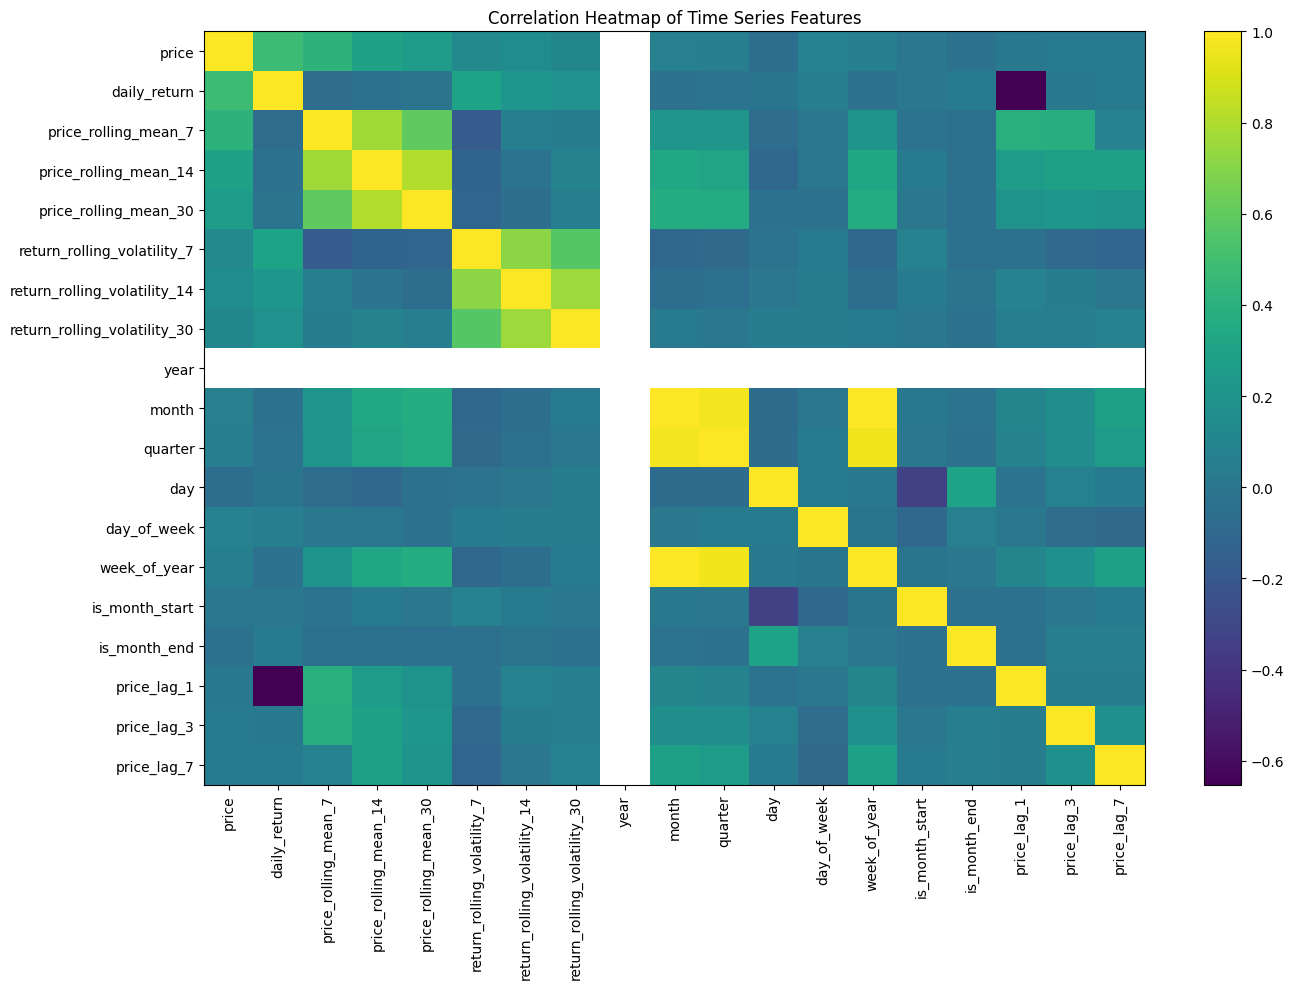

In [75]:
plt.figure(figsize=(14, 10))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Heatmap of Time Series Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 34. Time Series Modeling Readiness Check

Before forecasting, the dataset should satisfy the following:

- Date column is available
- Price column is numeric
- Data is sorted by asset and date
- Missing values are handled
- Lag features are available
- Rolling features are available
- Train-test split should be time-based

In [76]:
modeling_readiness = {
    "has_date_column": "date" in df_features.columns,
    "has_asset_column": "asset" in df_features.columns,
    "has_price_column": "price" in df_features.columns,
    "price_is_numeric": pd.api.types.is_numeric_dtype(df_features["price"]),
    "missing_values_total": int(df_features.isnull().sum().sum()),
    "has_daily_return": "daily_return" in df_features.columns,
    "has_lag_features": any(column.startswith("price_lag_") for column in df_features.columns),
    "has_rolling_features": any("rolling" in column for column in df_features.columns),
    "total_rows": len(df_features),
    "total_columns": len(df_features.columns)
}

modeling_readiness_df = pd.DataFrame([modeling_readiness])

modeling_readiness_df

,has_date_column,has_asset_column,has_price_column,price_is_numeric,missing_values_total,has_daily_return,has_lag_features,has_rolling_features,total_rows,total_columns
0,True,True,True,True,0,True,True,True,500,21


## 35. Save Time Series EDA Outputs

We save:

- Time series overview
- Asset time coverage
- Return summary
- Asset price ranking
- Monthly asset price
- Modeling readiness report
- Feature-engineered EDA dataset

In [77]:
time_series_overview_df.to_csv(TABLES_DIR / "02_time_series_overview.csv", index=False)
asset_time_coverage.to_csv(TABLES_DIR / "02_asset_time_coverage.csv", index=False)
return_summary.to_csv(TABLES_DIR / "02_return_summary.csv", index=False)
asset_price_ranking.to_csv(TABLES_DIR / "02_asset_price_ranking.csv", index=False)
monthly_asset_price.to_csv(TABLES_DIR / "02_monthly_asset_price.csv", index=False)
modeling_readiness_df.to_csv(TABLES_DIR / "02_modeling_readiness.csv", index=False)

df_features.to_csv(PROCESSED_DATA_DIR / "time_series_eda_features.csv", index=False)

print("Saved EDA outputs successfully.")
print(TABLES_DIR / "02_time_series_overview.csv")
print(TABLES_DIR / "02_asset_time_coverage.csv")
print(TABLES_DIR / "02_return_summary.csv")
print(TABLES_DIR / "02_asset_price_ranking.csv")
print(TABLES_DIR / "02_monthly_asset_price.csv")
print(TABLES_DIR / "02_modeling_readiness.csv")
print(PROCESSED_DATA_DIR / "time_series_eda_features.csv")

Saved EDA outputs successfully.
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\02_time_series_overview.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\02_asset_time_coverage.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\02_return_summary.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\02_asset_price_ranking.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\02_monthly_asset_price.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\02_modeling_readiness.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Mo

## 36. Key Observations


### Price Trend Observations

- Some assets may show stronger price movement than others.
- Sudden jumps or drops should be reviewed as possible anomalies.
- Rolling averages help smooth noisy price movement.

### Return Observations

- Daily returns show percentage price changes.
- Assets with wider return distribution are more volatile.
- Large return spikes may indicate abnormal market behavior.

### Volatility Observations

- Rolling volatility helps identify high-risk periods.
- High volatility periods are important for anomaly detection and portfolio monitoring.

### Anomaly Observations

- IQR and z-score methods provide simple rule-based anomaly checks.
- Final anomaly detection can be improved using machine learning models such as Isolation Forest.

### Modeling Readiness

- The dataset is suitable for forecasting after creating lag and rolling features.
- Train-test split should be time-based to avoid data leakage.